In [ ]:
# Install into THIS kernel (use %pip so Jupyter installs to the active interpreter)
%pip -q install -U imbalanced-learn xgboost scikit-learn pandas matplotlib seaborn joblib requests streamlit beautifulsoup4 lxml textblob


Note: you may need to restart the kernel to use updated packages.


In [11]:
import sys, subprocess, pkgutil

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pkg])

# Install required libs
for pkg in ["imbalanced-learn>=0.12", "xgboost>=2.0", "scikit-learn>=1.3"]:
    pip_install(pkg)

# Verify imports/versions
import imblearn, xgboost, sklearn
print("imbalanced-learn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)
print("scikit-learn:", sklearn.__version__)

imbalanced-learn: 0.14.0
xgboost: 3.0.5
scikit-learn: 1.7.2


In [13]:

# # News Popularity — SMOTE + XGBoost + Mini Streamlit App
# Dataset: UCI Online News Popularity
# Target: "popular" (1) if shares >= 1400 else 0
# Model: XGBoost (SMOTE on train only), quick hyperparameter search
# App: Streamlit single-file UI to demo predictions

import os, io, zipfile, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib, requests

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [14]:
# ## 1) Get / Load the dataset
# Tries local CSV first; otherwise downloads from UCI and extracts.

# %%
CSV_NAME = "OnlineNewsPopularity.csv"
UCI_ZIP  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00332/OnlineNewsPopularity.zip"

def ensure_dataset(csv_name=CSV_NAME):
    if os.path.exists(csv_name):
        return csv_name
    print("Downloading dataset zip from UCI...")
    r = requests.get(UCI_ZIP, timeout=60)
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    target_member = None
    for m in z.namelist():
        if m.lower().endswith(".csv"):
            target_member = m
            break
    assert target_member is not None, "CSV not found in the UCI zip."
    with z.open(target_member) as f_in, open(csv_name, "wb") as f_out:
        f_out.write(f_in.read())
    print("Saved:", csv_name)
    return csv_name

csv_path = ensure_dataset()
df_raw = pd.read_csv(csv_path)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw.head(3)

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500


In [15]:
# ## 2) Preprocess
# - Drop `url` & `timedelta`
# - Create binary label `popular` (shares >= 1400), then drop `shares`

# %%
df = df_raw.copy()
drop_cols = [c for c in df.columns if c.lower() in ["url", "timedelta"]]
df.drop(columns=drop_cols, inplace=True, errors="ignore")

df["popular"] = (df["shares"] >= 1400).astype(int)
df.drop(columns=["shares"], inplace=True)

FEATURE_COLUMNS = [c for c in df.columns if c != "popular"]
print("Shape:", df.shape, "| Features:", len(FEATURE_COLUMNS))
df.head(5)

Shape: (39644, 59) | Features: 58


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,popular
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


Missing values (total): 0

Class counts (0=not popular, 1=popular):


popular
0    18490
1    21154
Name: count, dtype: int64

Class ratio (1s): 0.534


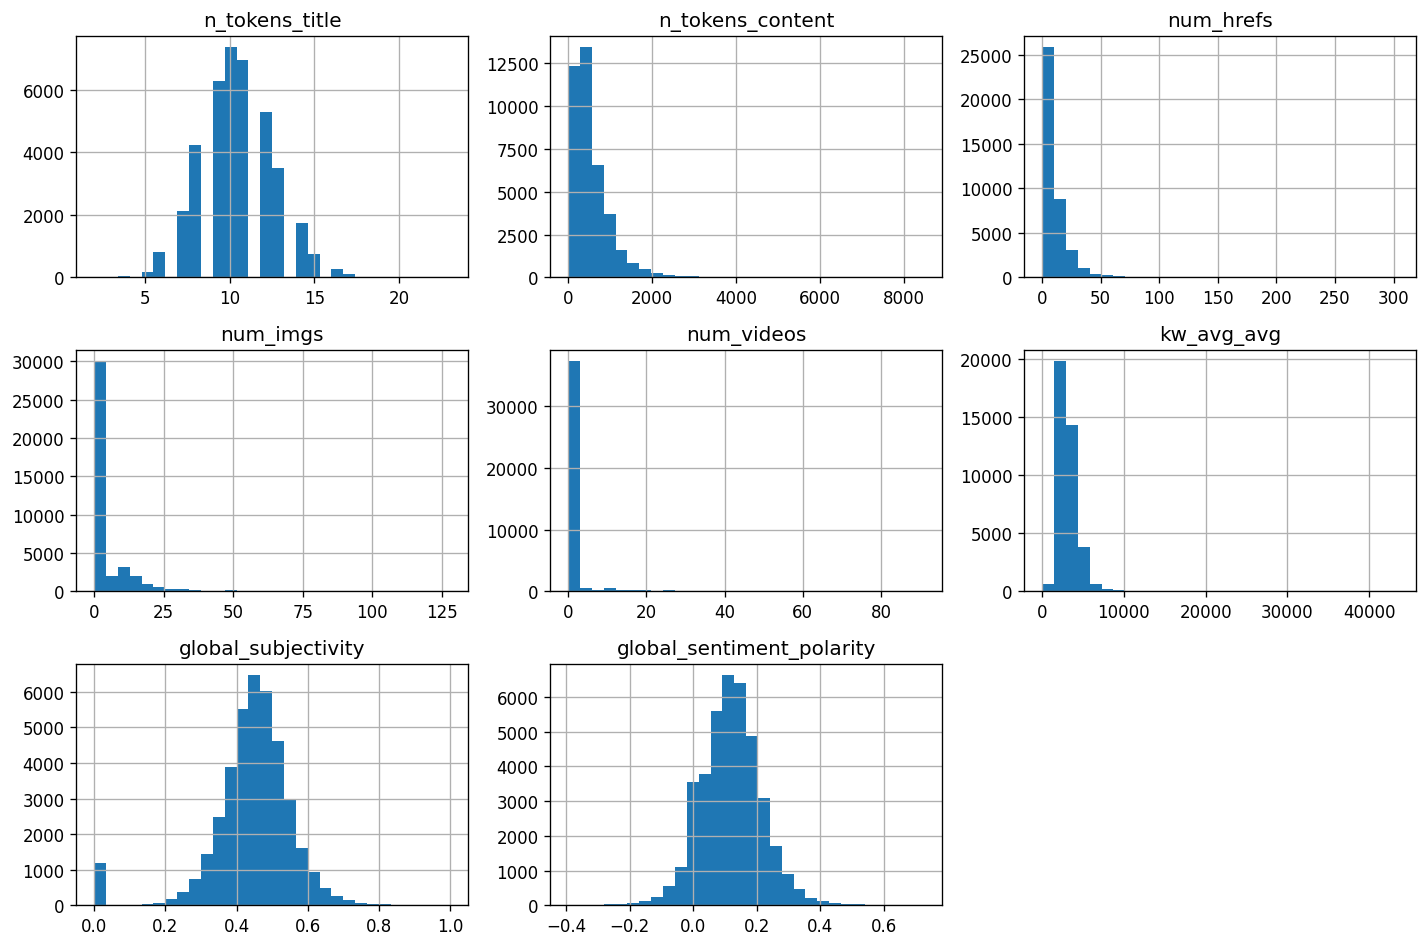

In [17]:
# ## 3) Quick EDA (safe & fast)

# %%
print("Missing values (total):", int(df.isna().sum().sum()))
class_counts = df["popular"].value_counts().sort_index()
print("\nClass counts (0=not popular, 1=popular):")
display(class_counts)
print("Class ratio (1s):", round(class_counts.get(1,0)/class_counts.sum(), 3))

# Show a handful of intuitive numeric distributions (skip if columns absent)
cand_cols = [c for c in [
    "n_tokens_title", "n_tokens_content", "num_hrefs", "num_imgs", "num_videos",
    "kw_avg_avg", "global_subjectivity", "global_sentiment_polarity", "is_weekend"
] if c in df.columns][:8]

if cand_cols:
    ax = df[cand_cols].hist(bins=30, figsize=(12,8))
    plt.tight_layout(); plt.show()


In [18]:
# ## 4) Train / Test split (stratified)

# %%
X = df[FEATURE_COLUMNS]
y = df["popular"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((31715, 58), (7929, 58))

In [19]:
# ## 5) SMOTE on the **training** data only (avoid leakage)

# %%
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After  SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [14792 16923]
After  SMOTE: [16923 16923]


In [22]:
# ## 6) XGBoost with a small GridSearchCV (paper-like but fast)
# Scoring by F1 to balance precision/recall.

# %%
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",    # fast/modern
    reg_lambda=1.0,
)

param_grid = {
    "max_depth": [6, 10],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 400],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    verbose=0,
)

grid.fit(X_train_sm, y_train_sm)
best_xgb = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}


Accuracy: 0.6662  |  Precision: 0.6801  |  Recall: 0.7069  |  F1: 0.6932  |  ROC-AUC: 0.7316

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.62      0.63      3698
           1       0.68      0.71      0.69      4231

    accuracy                           0.67      7929
   macro avg       0.66      0.66      0.66      7929
weighted avg       0.67      0.67      0.67      7929



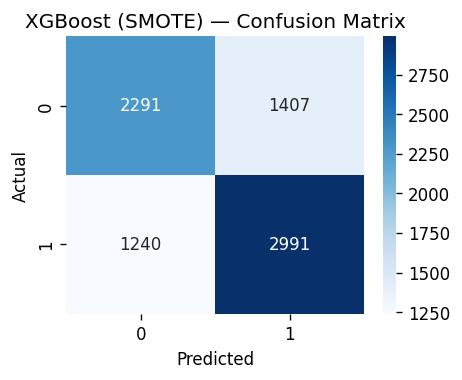

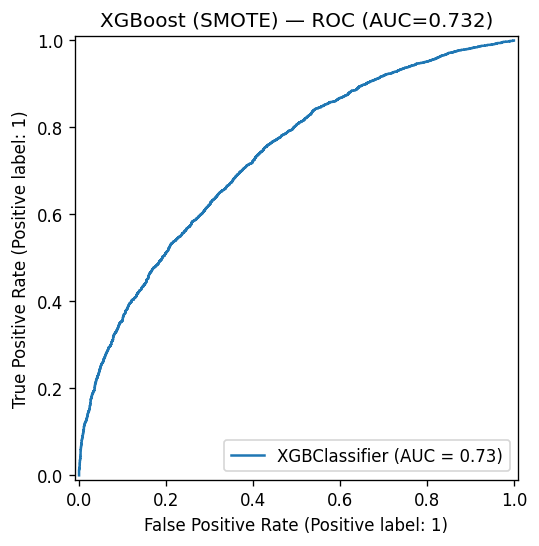

In [26]:
# %% [markdown]
# ## 7) Evaluate on the untouched test set

# %%
y_pred  = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
pr, rc, f1_bin, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}  |  Precision: {pr:.4f}  |  Recall: {rc:.4f}  |  F1: {f1:.4f}  |  ROC-AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost (SMOTE) — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title(f"XGBoost (SMOTE) — ROC (AUC={auc:.3f})")
plt.show()


data_channel_is_entertainment    78.966568
data_channel_is_tech             56.531311
data_channel_is_world            56.441414
data_channel_is_socmed           49.164165
is_weekend                       42.875641
kw_avg_avg                       32.493629
weekday_is_friday                30.645521
weekday_is_wednesday             28.829105
weekday_is_tuesday               24.298494
data_channel_is_bus              21.583462
kw_max_max                       21.125713
self_reference_min_shares        19.582088
self_reference_avg_sharess       18.478197
kw_min_min                       15.215857
num_videos                       15.089936
dtype: float64

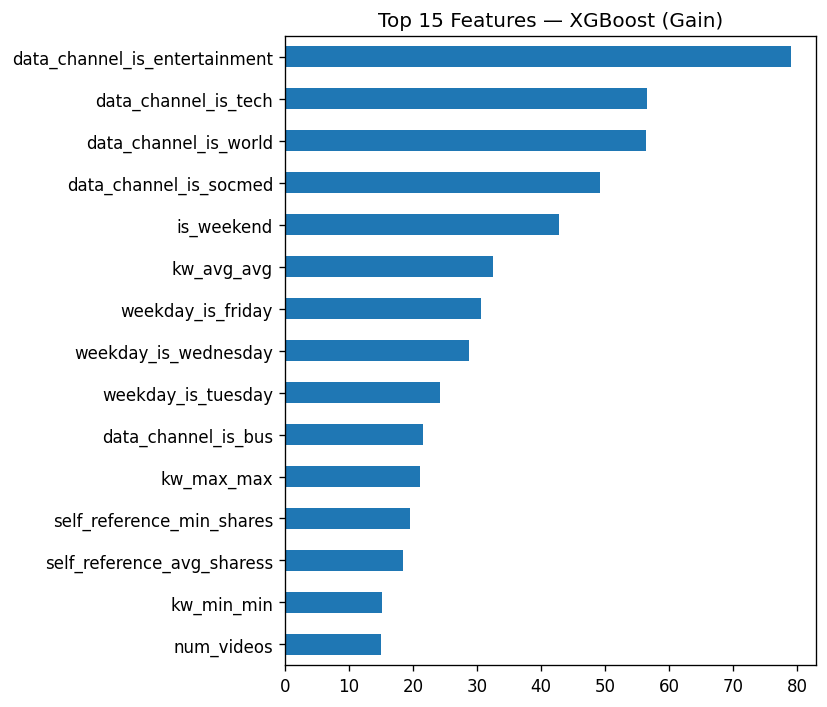

In [28]:
# ## 8) Feature importance (Gain) — **robust & numeric**
# Handles both 'f0..' keys and real feature names; casts to float; falls back to `feature_importances_` if needed.

# %%
def gain_importances_series(model, feature_columns):
    """Return a numeric pd.Series of gain importances indexed by feature names."""
    try:
        booster = model.get_booster()
        raw = booster.get_score(importance_type="gain") or {}
        mapped = {}

        for k, v in raw.items():
            # If xgboost kept the original column names as keys
            if k in feature_columns:
                mapped[k] = float(v)
                continue
            # If keys are like 'f0', 'f12', map by index
            if k.startswith("f") and k[1:].isdigit():
                idx = int(k[1:])
                if 0 <= idx < len(feature_columns):
                    mapped[feature_columns[idx]] = float(v)

        s = pd.Series(mapped, dtype="float64")
        if not s.empty:
            return s

    except Exception:
        pass

    # Fallback to model.feature_importances_
    try:
        imp = np.asarray(model.feature_importances_, dtype=float)
        if imp.size == len(feature_columns):
            return pd.Series(imp, index=feature_columns, dtype="float64")
    except Exception:
        pass

    # Last resort: empty series
    return pd.Series(dtype="float64")

imp_series = gain_importances_series(best_xgb, FEATURE_COLUMNS).sort_values(ascending=False).head(15)

display(imp_series)

if not imp_series.empty:
    plt.figure(figsize=(7,6))
    imp_series.sort_values().plot.barh()
    plt.title("Top 15 Features — XGBoost (Gain)")
    plt.tight_layout(); plt.show()
else:
    print("No importances available to plot.")


In [30]:
# ## 9) Save artifacts for the future web app

# %%
ART_MODEL = "model_xgb_smote_best.joblib"
ART_COLS  = "feature_columns.json"
ART_MEANS = "feature_means.json"

joblib.dump(best_xgb, ART_MODEL)

with open(ART_COLS, "w") as f:
    json.dump(FEATURE_COLUMNS, f)

FEATURE_MEANS = df[FEATURE_COLUMNS].mean(numeric_only=True).to_dict()
with open(ART_MEANS, "w") as f:
    json.dump(FEATURE_MEANS, f)

print("Saved artifacts ->", ART_MODEL, ART_COLS, ART_MEANS)


Saved artifacts -> model_xgb_smote_best.joblib feature_columns.json feature_means.json
